## **TECHNICAL TEST**

**Veni Zahara Kartika**

### **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from prophet import Prophet
plt.style.use('default')
pd.set_option('display.max_columns', None)

### **Dataset**

In [2]:
customer = pd.read_csv('Customer_Master.csv')
transactions = pd.read_csv('Transactions.csv')

### **Data Preparation**

In [3]:
# Mengubah Datetime
transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date']
)

customer['First_Transaction_Date'] = pd.to_datetime(
    customer['First_Transaction_Date']
)

customer['Last_Transaction_Date'] = pd.to_datetime(
    customer['Last_Transaction_Date']
)

In [4]:
# Cek Missing Value
customer.isnull().sum()
transactions.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Transaction_Date,0
Product_Category,0
Quantity,0
Unit_Price,0
Total_Transaction_Value,0
Sales_Channel,0
Payment_Method,0


In [5]:
# Cek Duplikat
customer.duplicated().sum()
transactions.duplicated().sum()

np.int64(0)

### **EDA Data Customer Master**

In [6]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Customer_ID                  10000 non-null  object        
 1   Customer_Name                10000 non-null  object        
 2   Region                       10000 non-null  object        
 3   Customer_Segment             10000 non-null  object        
 4   Risk_Profile                 10000 non-null  object        
 5   Estimated_Annual_Value       10000 non-null  int64         
 6   Estimated_Transaction_Count  10000 non-null  int64         
 7   First_Transaction_Date       10000 non-null  datetime64[ns]
 8   Last_Transaction_Date        10000 non-null  datetime64[ns]
 9   Customer_Loyalty             10000 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 781.4+ KB


In [7]:
customer.describe()

,Estimated_Annual_Value,Estimated_Transaction_Count,First_Transaction_Date,Last_Transaction_Date
count,1.000000e+04,10000.000000,10000,10000
mean,1.006533e+07,17.637300,2023-08-26 16:16:01.919999744,2025-09-10 18:09:30.240000
min,5.000790e+05,1.000000,2023-01-21 00:00:00,2023-01-25 00:00:00
25%,4.567928e+06,8.000000,2023-05-27 00:00:00,2024-09-14 18:00:00
50%,8.128016e+06,14.000000,2023-08-27 00:00:00,2025-10-05 00:00:00
75%,1.521694e+07,27.000000,2023-11-27 00:00:00,2026-11-18 00:00:00
max,2.499658e+07,40.000000,2024-03-27 00:00:00,2026-12-31 00:00:00
std,6.764009e+06,11.395365,NaN,NaN


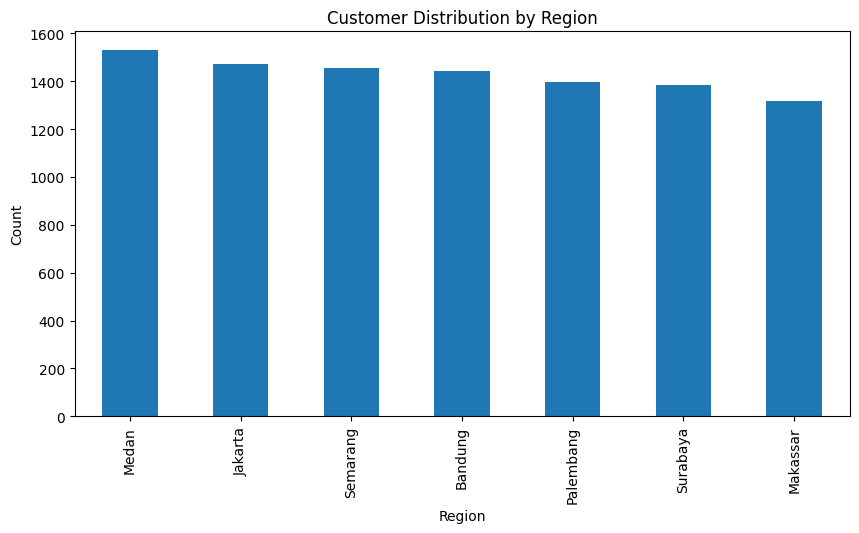

In [18]:
customer['Region'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Customer Distribution by Region')
plt.ylabel('Count')
plt.show()

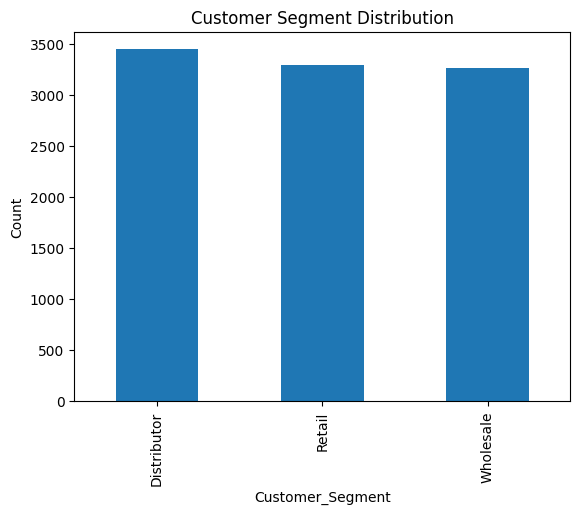

In [19]:
customer['Customer_Segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segment Distribution')
plt.ylabel('Count')
plt.show()

### **EDA Data Transactions**

In [10]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146144 entries, 0 to 146143
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Transaction_ID           146144 non-null  object        
 1   Customer_ID              146144 non-null  object        
 2   Transaction_Date         146144 non-null  datetime64[ns]
 3   Product_Category         146144 non-null  object        
 4   Quantity                 146144 non-null  int64         
 5   Unit_Price               146144 non-null  int64         
 6   Total_Transaction_Value  146144 non-null  int64         
 7   Sales_Channel            146144 non-null  object        
 8   Payment_Method           146144 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 10.0+ MB


In [11]:
transactions.describe()

,Transaction_Date,Quantity,Unit_Price,Total_Transaction_Value
count,146144,146144.000000,1.461440e+05,1.461440e+05
mean,2024-12-12 07:34:02.982264064,25.465055,1.072440e+06,2.731845e+07
min,2023-01-21 00:00:00,1.000000,1.500040e+05,1.501800e+05
25%,2024-02-25 00:00:00,13.000000,6.109332e+05,9.289187e+06
50%,2024-10-28 00:00:00,25.000000,1.071421e+06,2.141311e+07
75%,2025-09-13 00:00:00,38.000000,1.534689e+06,4.079205e+07
max,2026-12-31 00:00:00,50.000000,1.999999e+06,9.998960e+07
std,NaN,14.444886,5.338343e+05,2.200170e+07


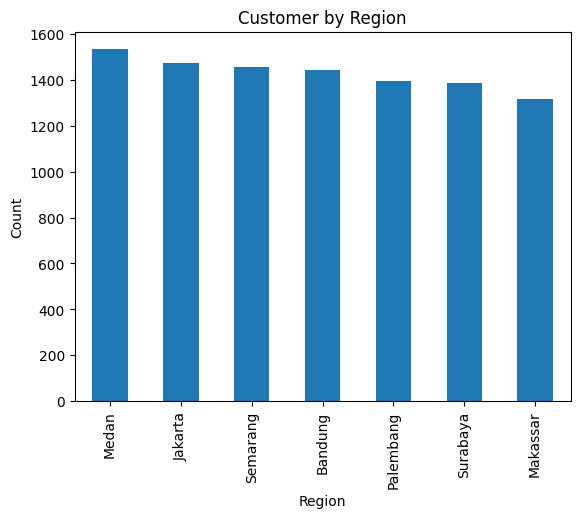

In [20]:
customer['Region'].value_counts().plot(
    kind='bar'
)

plt.title('Customer by Region')
plt.ylabel('Count')
plt.show()

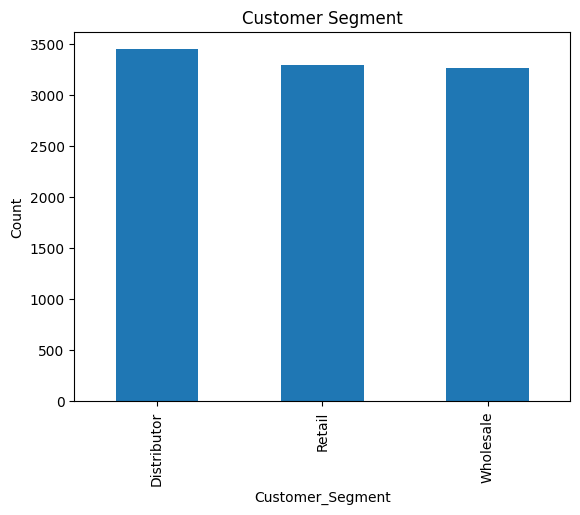

In [21]:
customer['Customer_Segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segment')
plt.ylabel('Count')
plt.show()

### **Customer Aggregation**

In [22]:
customer_summary = (
    transactions
    .groupby('Customer_ID')
    .agg(
        Total_Transactions=(
            'Transaction_ID',
            'count'
        ),
        Total_Spend=(
            'Total_Transaction_Value',
            'sum'
        ),
        Avg_Spend=(
            'Total_Transaction_Value',
            'mean'
        ),
        First_Purchase=(
            'Transaction_Date',
            'min'
        ),
        Last_Purchase=(
            'Transaction_Date',
            'max'
        )
    )
    .reset_index()
)

In [23]:
customer_df = customer.merge(
    customer_summary,
    on='Customer_ID',
    how='left'
)

In [24]:
customer_df

,Customer_ID,Customer_Name,Region,Customer_Segment,Risk_Profile,Estimated_Annual_Value,Estimated_Transaction_Count,First_Transaction_Date,Last_Transaction_Date,Customer_Loyalty,Total_Transactions,Total_Spend,Avg_Spend,First_Purchase,Last_Purchase
0,CUST00001,Perum Hariyah Pudjiastuti,Surabaya,Retail,Medium Risk,8220576,6,2023-04-21,2024-03-05,Medium Potential,6,131804086,2.196735e+07,2023-04-21,2024-03-05
1,CUST00002,PT Nababan,Semarang,Distributor,Low Risk,8439167,38,2023-05-22,2026-12-15,High Potential Long-term,27,733303080,2.715937e+07,2023-05-22,2026-12-15
2,CUST00003,PT Siregar Adriansyah,Jakarta,Retail,High Risk,4039336,1,2023-12-18,2023-12-18,At Risk,1,25617132,2.561713e+07,2023-12-18,2023-12-18
3,CUST00004,Perum Pratiwi,Makassar,Retail,Low Risk,21956909,22,2023-10-23,2026-09-13,High Potential Long-term,22,674129377,3.064224e+07,2023-10-23,2026-09-13
4,CUST00005,PT Pangestu Tbk,Bandung,Wholesale,Medium Risk,5519187,14,2023-08-06,2025-03-01,Medium Potential,14,400096109,2.857829e+07,2023-08-06,2025-03-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST09996,UD Tamba Tbk,Bandung,Distributor,Medium Risk,4994447,10,2023-10-12,2024-12-24,Medium Potential,10,345832368,3.458324e+07,2023-10-12,2024-12-24
9996,CUST09997,PT Putra Tbk,Surabaya,Distributor,High Risk,652489,5,2023-03-10,2023-12-12,At Risk,5,65699321,1.313986e+07,2023-03-10,2023-12-12
9997,CUST09998,PT Nasyiah Tbk,Medan,Distributor,High Risk,3999047,5,2023-05-20,2023-09-01,At Risk,5,109376516,2.187530e+07,2023-05-20,2023-09-01
9998,CUST09999,Perum Zulkarnain,Surabaya,Retail,Low Risk,8506095,25,2023-04-10,2026-12-09,High Potential Long-term,25,636362725,2.545451e+07,2023-04-10,2026-12-09


### **Retention & Churn Analysis**

In [34]:
# Date Year
transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date']
)

transactions['Year'] = (
    transactions['Transaction_Date']
    .dt.year
)

In [35]:
# Customer unik per tahun
customer_year = (
    transactions[
        ['Customer_ID', 'Year']
    ]
    .drop_duplicates()
)

In [36]:
analysis = []

years = sorted(
    customer_year['Year'].unique()
)

for i in range(len(years) - 1):

    current_year = years[i]
    next_year = years[i + 1]

    current_customer = set(
        customer_year.loc[
            customer_year['Year'] == current_year,
            'Customer_ID'
        ]
    )

    next_customer = set(
        customer_year.loc[
            customer_year['Year'] == next_year,
            'Customer_ID'
        ]
    )

    retained_customer = (
        current_customer
        &
        next_customer
    )

    churn_customer = (
        current_customer
        -
        next_customer
    )

    active_customer = len(current_customer)

    retention_rate = (
        len(retained_customer)
        /
        active_customer
        * 100
    )

    churn_rate = (
        len(churn_customer)
        /
        active_customer
        * 100
    )

    analysis.append({
        'Year': current_year,
        'Next_Year': next_year,
        'Active_Customer': active_customer,
        'Retained_Customer': len(retained_customer),
        'Churn_Customer': len(churn_customer),
        'Retention_Rate': round(retention_rate, 2),
        'Churn_Rate': round(churn_rate, 2)
    })

analysis_df = pd.DataFrame(analysis)

analysis_df

,Year,Next_Year,Active_Customer,Retained_Customer,Churn_Customer,Retention_Rate,Churn_Rate
0,2023,2024,8474,7608,866,89.78,10.22
1,2024,2025,9134,6749,2385,73.89,26.11
2,2025,2026,6749,4599,2150,68.14,31.86


### **Customer Segmentation**

In [42]:
# RFM
analysis_date = pd.Timestamp('2026-12-31')

rfm = (
    transactions
    .groupby('Customer_ID')
    .agg(
        Recency=(
            'Transaction_Date',
            lambda x:
            (analysis_date - x.max()).days
        ),
        Frequency=(
            'Transaction_ID',
            'count'
        ),
        Monetary=(
            'Total_Transaction_Value',
            'sum'
        )
    )
    .reset_index()
)

In [43]:
# R Score
rfm['R_Score'] = np.select(
    [
        rfm['Recency'] <= 30,
        rfm['Recency'] <= 90,
        rfm['Recency'] <= 180,
        rfm['Recency'] <= 365
    ],
    [5, 4, 3, 2],
    default=1
)

In [44]:
# F Score
rfm['F_Score'] = np.select(
    [
        rfm['Frequency'] >= 20,
        rfm['Frequency'] >= 15,
        rfm['Frequency'] >= 10,
        rfm['Frequency'] >= 5
    ],
    [5, 4, 3, 2],
    default=1
)

In [45]:
# M Score
rfm['M_Score'] = np.select(
    [
        rfm['Monetary'] >= 10000000,
        rfm['Monetary'] >= 5000000,
        rfm['Monetary'] >= 2000000,
        rfm['Monetary'] >= 1000000
    ],
    [5, 4, 3, 2],
    default=1
)

In [46]:
# Total Score
rfm['Total_RFM_Score'] = (
    rfm['R_Score']
    + rfm['F_Score']
    + rfm['M_Score']
)

In [47]:
# Customer Risk
rfm['Customer_Risk'] = np.select(
    [
        rfm['Total_RFM_Score'] >= 12,
        rfm['Total_RFM_Score'] >= 7
    ],
    [
        'Low Risk',
        'Medium Risk'
    ],
    default='High Risk'
)

In [48]:
rfm

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_RFM_Score,Customer_Risk
0,CUST00001,1031,6,131804086,1,2,5,8,Medium Risk
1,CUST00002,16,27,733303080,5,5,5,15,Low Risk
2,CUST00003,1109,1,25617132,1,1,5,7,Medium Risk
3,CUST00004,109,22,674129377,3,5,5,13,Low Risk
4,CUST00005,670,14,400096109,1,3,5,9,Medium Risk
...,...,...,...,...,...,...,...,...,...
9995,CUST09996,737,10,345832368,1,3,5,9,Medium Risk
9996,CUST09997,1115,5,65699321,1,2,5,8,Medium Risk
9997,CUST09998,1217,5,109376516,1,2,5,8,Medium Risk
9998,CUST09999,22,25,636362725,5,5,5,15,Low Risk


In [49]:
# Summary
customer_risk_summary = (
    rfm.groupby('Customer_Risk')
    .size()
    .reset_index(name='Total_Customer')
)

customer_risk_summary['Percentage'] = (
    customer_risk_summary['Total_Customer']
    /
    customer_risk_summary['Total_Customer'].sum()
    * 100
).round(2)

customer_risk_summary

,Customer_Risk,Total_Customer,Percentage
0,High Risk,101,1.01
1,Low Risk,4122,41.22
2,Medium Risk,5777,57.77


### **Loyal Customer Analysis**

In [54]:
# Customer Lifetime Value
top_clv = (
    rfm
    .sort_values(
        'Monetary',
        ascending=False
    )
    .head(10)
)
top_clv

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_RFM_Score,Customer_Risk
1730,CUST01731,43,27,1179149496,4,5,5,14,Low Risk
8879,CUST08880,49,28,1134987462,4,5,5,14,Low Risk
720,CUST00721,41,28,1090526053,4,5,5,14,Low Risk
1863,CUST01864,2,29,1064493995,5,5,5,15,Low Risk
4854,CUST04855,21,24,1046045490,5,5,5,15,Low Risk
4162,CUST04163,8,27,1031009931,5,5,5,15,Low Risk
878,CUST00879,38,27,1022512197,4,5,5,14,Low Risk
6546,CUST06547,25,25,1007388239,5,5,5,15,Low Risk
6792,CUST06793,96,27,1000071544,3,5,5,13,Low Risk
8457,CUST08458,3,30,994126236,5,5,5,15,Low Risk


In [55]:
# Frekuensi Tertinggi
top_frequency = (
    rfm
    .sort_values(
        'Frequency',
        ascending=False
    )
    .head(10)
)
top_frequency

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_RFM_Score,Customer_Risk
2477,CUST02478,29,31,674841466,5,5,5,15,Low Risk
674,CUST00675,42,30,727944282,4,5,5,14,Low Risk
9661,CUST09662,3,30,966033760,5,5,5,15,Low Risk
833,CUST00834,14,30,871022608,5,5,5,15,Low Risk
3930,CUST03931,19,30,740065219,5,5,5,15,Low Risk
896,CUST00897,38,30,745311822,4,5,5,14,Low Risk
3521,CUST03522,5,30,907633796,5,5,5,15,Low Risk
8457,CUST08458,3,30,994126236,5,5,5,15,Low Risk
6686,CUST06687,68,30,679340009,4,5,5,14,Low Risk
8178,CUST08179,15,30,701699437,5,5,5,15,Low Risk


In [56]:
# Loyal Jangka Panjang
customer_df['Customer_Age_Days'] = (
    customer_df['Last_Purchase']
    -
    customer_df['First_Purchase']
).dt.days

long_term_loyal = (
    customer_df
    .sort_values(
        by=[
            'Customer_Age_Days',
            'Total_Transactions'
        ],
        ascending=False
    )
    .head(10)
)
long_term_loyal

,Customer_ID,Customer_Name,Region,Customer_Segment,Risk_Profile,Estimated_Annual_Value,Estimated_Transaction_Count,First_Transaction_Date,Last_Transaction_Date,Customer_Loyalty,Total_Transactions,Total_Spend,Avg_Spend,First_Purchase,Last_Purchase,Customer_Age_Days
2023,CUST02024,CV Hidayanto Tbk,Surabaya,Wholesale,Low Risk,22084524,35,2023-01-27,2026-12-26,High Potential Long-term,29,776558133,2.677787e+07,2023-01-27,2026-12-26,1429
5538,CUST05539,CV Puspasari (Persero) Tbk,Surabaya,Retail,Low Risk,15336960,31,2023-02-02,2026-12-31,High Potential Long-term,28,871221871,3.111507e+07,2023-02-02,2026-12-31,1428
5160,CUST05161,UD Najmudin Pranowo (Persero) Tbk,Jakarta,Retail,Low Risk,6732002,34,2023-02-01,2026-12-28,High Potential Long-term,26,866410332,3.332347e+07,2023-02-01,2026-12-28,1426
2363,CUST02364,PT Uyainah Puspasari,Jakarta,Distributor,Low Risk,18505803,29,2023-02-07,2026-12-31,High Potential Long-term,29,520012819,1.793148e+07,2023-02-07,2026-12-31,1423
850,CUST00851,PD Sihombing (Persero) Tbk,Medan,Retail,Low Risk,22005227,37,2023-01-28,2026-12-20,High Potential Long-term,26,648702731,2.495011e+07,2023-01-28,2026-12-20,1422
5599,CUST05600,CV Gunarto,Semarang,Distributor,Low Risk,17800518,34,2023-02-05,2026-12-26,High Potential Long-term,29,811831917,2.799420e+07,2023-02-05,2026-12-26,1420
7316,CUST07317,UD Novitasari (Persero) Tbk,Jakarta,Retail,Low Risk,8574341,40,2023-02-09,2026-12-30,High Potential Long-term,29,722819693,2.492482e+07,2023-02-09,2026-12-30,1420
8092,CUST08093,PD Prasetyo (Persero) Tbk,Surabaya,Distributor,Low Risk,5558958,28,2023-02-03,2026-12-24,High Potential Long-term,24,684490704,2.852045e+07,2023-02-03,2026-12-24,1420
929,CUST00930,PT Anggriawan (Persero) Tbk,Palembang,Distributor,Low Risk,5966912,26,2023-02-08,2026-12-27,High Potential Long-term,26,921102836,3.542703e+07,2023-02-08,2026-12-27,1418
2462,CUST02463,Perum Waskita (Persero) Tbk,Palembang,Wholesale,Low Risk,16476258,28,2023-02-16,2026-12-30,High Potential Long-term,25,600781377,2.403126e+07,2023-02-16,2026-12-30,1413


In [66]:
# Future Potential Customer
future_potential = rfm[
    (rfm['Customer_Risk'] != 'High Risk')
].copy()

future_potential['Future_Potential_Score'] = (
      future_potential['R_Score'] * 0.4
    + future_potential['F_Score'] * 0.4
    + (6 - future_potential['M_Score']) * 0.2
)

future_potential = (
    future_potential
    .sort_values(
        'Future_Potential_Score',
        ascending=False
    )
)

future_potential

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Total_RFM_Score,Customer_Risk,Future_Potential_Score
9994,CUST09995,22,21,385254056,5,5,5,15,Low Risk,4.2
7052,CUST07053,3,21,610735264,5,5,5,15,Low Risk,4.2
7057,CUST07058,13,20,585020166,5,5,5,15,Low Risk,4.2
7060,CUST07061,28,24,767186830,5,5,5,15,Low Risk,4.2
7061,CUST07062,1,26,790946784,5,5,5,15,Low Risk,4.2
...,...,...,...,...,...,...,...,...,...,...
2620,CUST02621,996,3,36262042,1,1,5,7,Medium Risk,1.0
2621,CUST02622,1064,2,117525404,1,1,5,7,Medium Risk,1.0
2591,CUST02592,1104,4,116005214,1,1,5,7,Medium Risk,1.0
2701,CUST02702,961,3,70227201,1,1,5,7,Medium Risk,1.0


### **Customer Behavior Analysis**

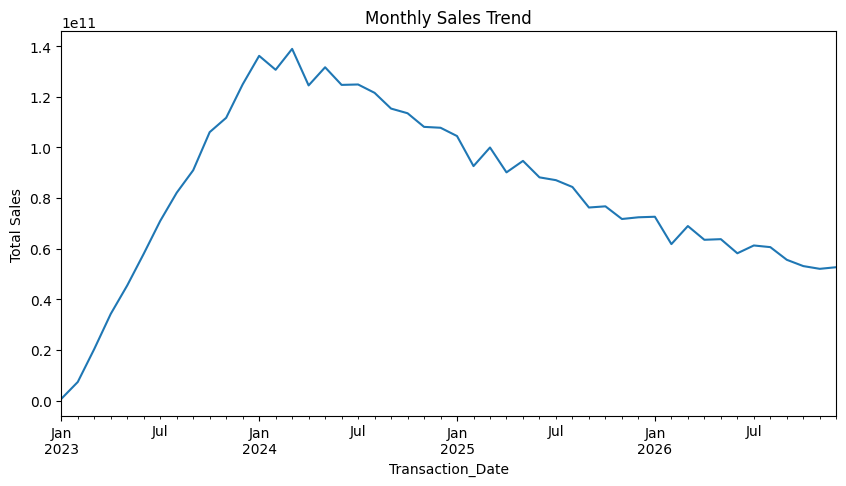

In [73]:
# Pola Pembelian
monthly_sales = (
    transactions
    .groupby(
        transactions[
            'Transaction_Date'
        ]
        .dt.to_period('M')
    )
    ['Total_Transaction_Value']
    .sum()
)

monthly_sales.plot(
    kind='line',
    figsize=(10,5)
)

plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()

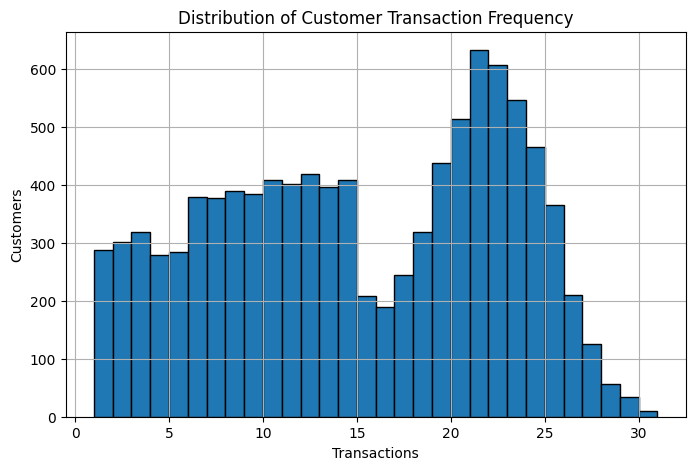

In [78]:
# Frekuensi Transaksi
# Frekuensi Transaksi
plt.figure(figsize=(8, 5))

rfm['Frequency'].hist(
    bins=30,
    edgecolor='black'
)

plt.title(
    'Distribution of Customer Transaction Frequency',
)
plt.xlabel('Transactions')
plt.ylabel('Customers')

plt.show()

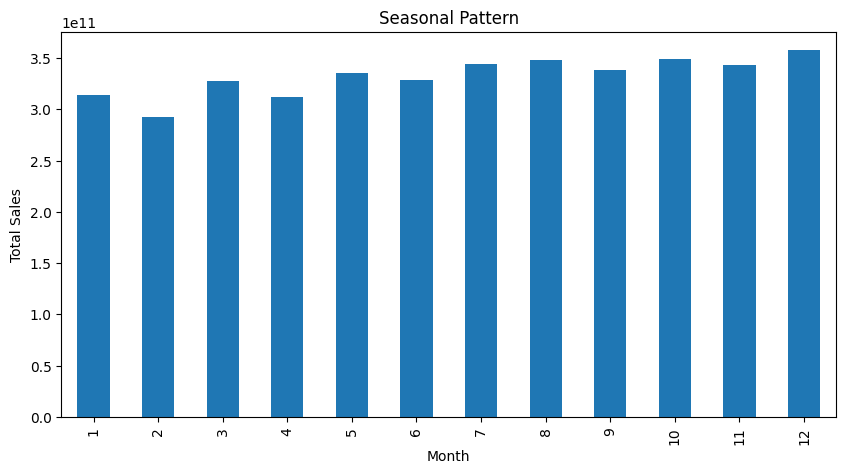

In [71]:
# Seasonal Pattern
transactions['Month'] = (
    transactions[
        'Transaction_Date'
    ].dt.month
)

seasonality = (
    transactions
    .groupby('Month')
    ['Total_Transaction_Value']
    .sum()
)

seasonality.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Seasonal Pattern')
plt.ylabel('Total Sales')
plt.show()

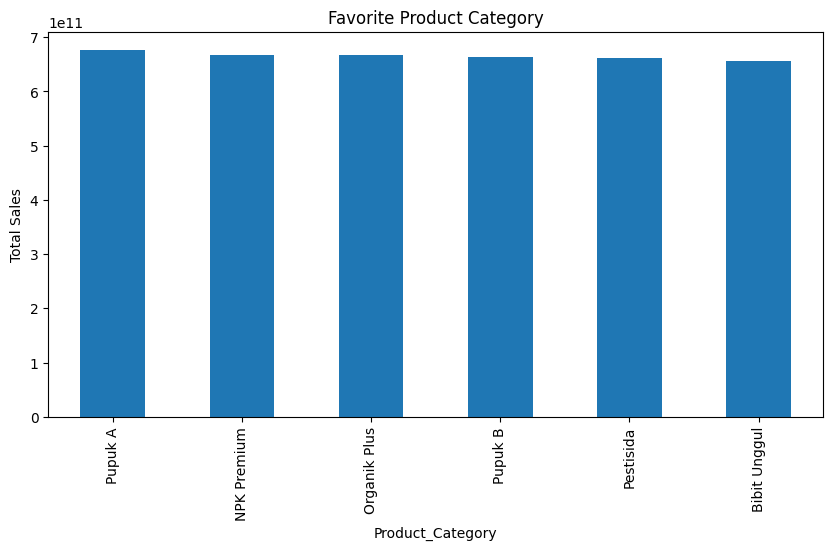

In [80]:
# Kategori Favorit
favorite_category = (
    transactions
    .groupby(
        'Product_Category'
    )
    ['Total_Transaction_Value']
    .sum()
    .sort_values(
        ascending=False
    )
)

favorite_category.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Favorite Product Category')
plt.ylabel('Total Sales')
plt.show()

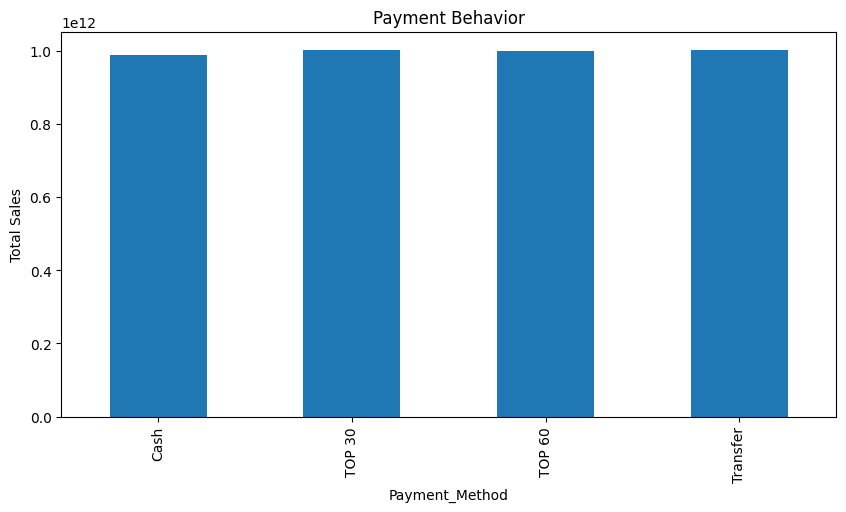

In [81]:
# Payment Behavior
payment_behavior = (
    transactions
    .groupby(
        'Payment_Method'
    )
    ['Total_Transaction_Value']
    .sum()
)

payment_behavior.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Payment Behavior')
plt.ylabel('Total Sales')
plt.show()

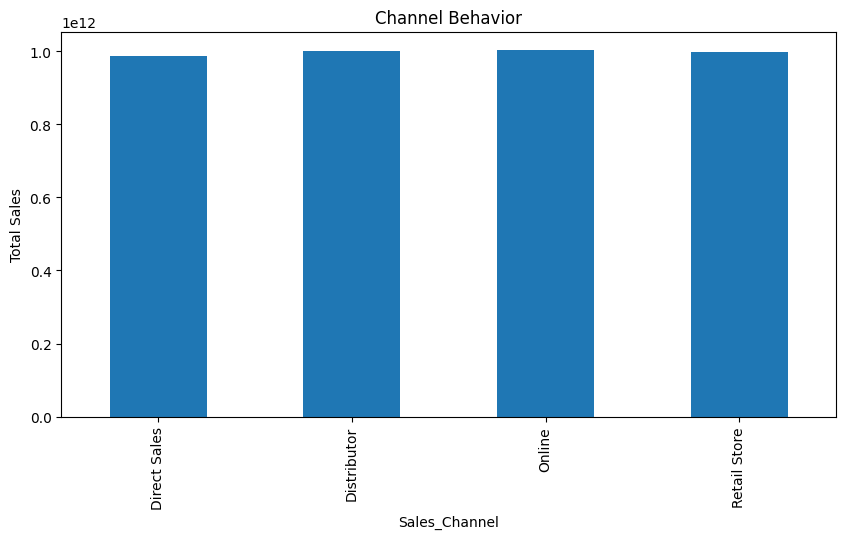

In [82]:
# Channel behavior
channel_behavior = (
    transactions
    .groupby(
        'Sales_Channel'
    )
    ['Total_Transaction_Value']
    .sum()
)

channel_behavior.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Channel Behavior')
plt.ylabel('Total Sales')
plt.show()

### **Predictive Analysis**

In [83]:
model_df = rfm.copy()

model_df['Churn'] = np.where(
    model_df['Recency'] > 365,
    1,
    0
)

In [84]:
X = model_df[
    [
        'Recency',
        'Frequency',
        'Monetary'
    ]
]

y = model_df['Churn']

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

pred = model.predict(X_test)

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       911
           1       1.00      1.00      1.00      1089

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### **Forecasting**

In [92]:
revenue = (
    transactions
    .groupby('Transaction_Date', as_index=False)
    ['Total_Transaction_Value']
    .sum()
)

revenue = revenue.rename(
    columns={
        'Transaction_Date': 'ds',
        'Total_Transaction_Value': 'y'
    }
)

revenue['ds'] = pd.to_datetime(revenue['ds'])

revenue.head()


,ds,y
0,2023-01-21,64061551
1,2023-01-22,21450165
2,2023-01-24,31673691
3,2023-01-25,43136797
4,2023-01-26,22933136


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


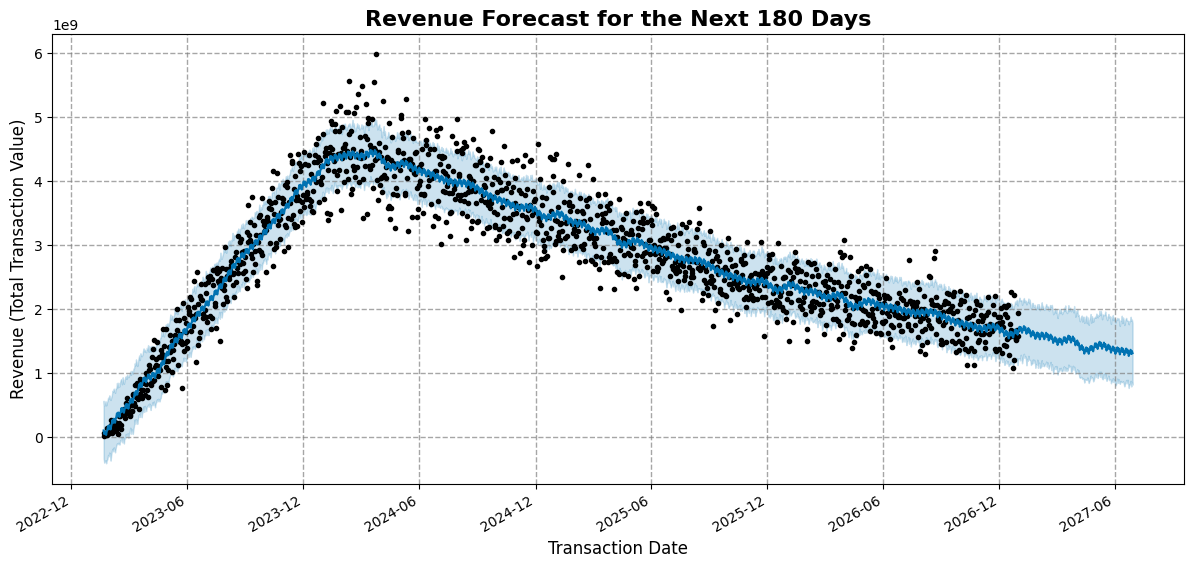

In [93]:
model = Prophet()

model.fit(revenue)

future = model.make_future_dataframe(
    periods=180
)

forecast = model.predict(
    future
)

fig = model.plot(
    forecast,
    figsize=(12, 6)
)

ax = fig.gca()
ax.set_title(
    'Revenue Forecast for the Next 180 Days',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Transaction Date',
    fontsize=12
)

ax.set_ylabel(
    'Revenue (Total Transaction Value)',
    fontsize=12
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.7
)

fig.autofmt_xdate()
plt.show()

### **Export**

In [94]:
# Dataset untuk Power BI
customer_segment = rfm.copy()
retention = analysis_df.copy()

# Export CSV
customer_summary.to_csv(
    'customer_summary.csv',
    index=False
)

customer_segment.to_csv(
    'customer_segment.csv',
    index=False
)

retention.to_csv(
    'retention.csv',
    index=False
)

transactions.to_csv(
    'Transactions.csv',
    index=False
)